# Student Performance Prediction - Machine Learning Project

## Project Overview
This notebook demonstrates a complete machine learning workflow for predicting student academic performance based on various features such as study hours, attendance, previous grades, and other factors.

**Goal**: Build a supervised learning model to predict student final grades with ~80% accuracy.

**Key Steps**:
1. Data Loading and Exploration
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing and Feature Engineering
4. Model Training and Evaluation
5. Results Analysis and Insights

## 1. Import Libraries

In [6]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


✓ Libraries imported successfully!


## 2. Load and Explore Data

In [7]:
# Load the dataset
df = pd.read_csv('data/student_data.csv')

print("Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Students: {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")

Dataset loaded successfully!

Dataset Shape: (100, 9)
Number of Students: 100
Number of Features: 9


In [8]:
# Display first few rows
print("\n=== First 5 Rows ===")
df.head()


=== First 5 Rows ===


,Student_ID,Study_Hours_Per_Week,Previous_Grade,Attendance_Percentage,Participation_Score,Sleep_Hours,Extracurricular_Activities,Parental_Support,Final_Grade
0,1,15,75,92,8,7,2,High,78
1,2,10,68,85,6,6,1,Medium,70
2,3,20,82,95,9,8,3,High,85
3,4,8,60,78,5,5,0,Low,62
4,5,18,88,98,10,7,2,High,90


In [9]:
# Dataset information
print("\n=== Dataset Information ===")
df.info()


=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Student_ID                  100 non-null    int64
 1   Study_Hours_Per_Week        100 non-null    int64
 2   Previous_Grade              100 non-null    int64
 3   Attendance_Percentage       100 non-null    int64
 4   Participation_Score         100 non-null    int64
 5   Sleep_Hours                 100 non-null    int64
 6   Extracurricular_Activities  100 non-null    int64
 7   Parental_Support            100 non-null    str  
 8   Final_Grade                 100 non-null    int64
dtypes: int64(8), str(1)
memory usage: 7.2 KB


In [10]:
# Statistical summary
print("\n=== Statistical Summary ===")
df.describe()


=== Statistical Summary ===


,Student_ID,Study_Hours_Per_Week,Previous_Grade,Attendance_Percentage,Participation_Score,Sleep_Hours,Extracurricular_Activities,Final_Grade
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,13.660000,75.200000,87.480000,7.150000,6.570000,1.580000,77.280000
std,29.011492,4.952746,10.423361,8.067243,1.950783,1.056533,1.036505,10.191183
min,1.000000,5.000000,52.000000,68.000000,3.000000,4.000000,0.000000,55.000000
25%,25.750000,9.750000,66.000000,80.000000,5.750000,6.000000,1.000000,69.000000
50%,50.500000,13.000000,76.500000,89.000000,7.000000,7.000000,2.000000,78.000000
75%,75.250000,18.000000,84.000000,94.000000,9.000000,7.000000,2.000000,86.000000
max,100.000000,22.000000,91.000000,99.000000,10.000000,8.000000,3.000000,93.000000


In [11]:
# Check for missing values
print("\n=== Missing Values ===")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")


=== Missing Values ===
Student_ID                    0
Study_Hours_Per_Week          0
Previous_Grade                0
Attendance_Percentage         0
Participation_Score           0
Sleep_Hours                   0
Extracurricular_Activities    0
Parental_Support              0
Final_Grade                   0
dtype: int64

Total missing values: 0


## 3. Exploratory Data Analysis (EDA)

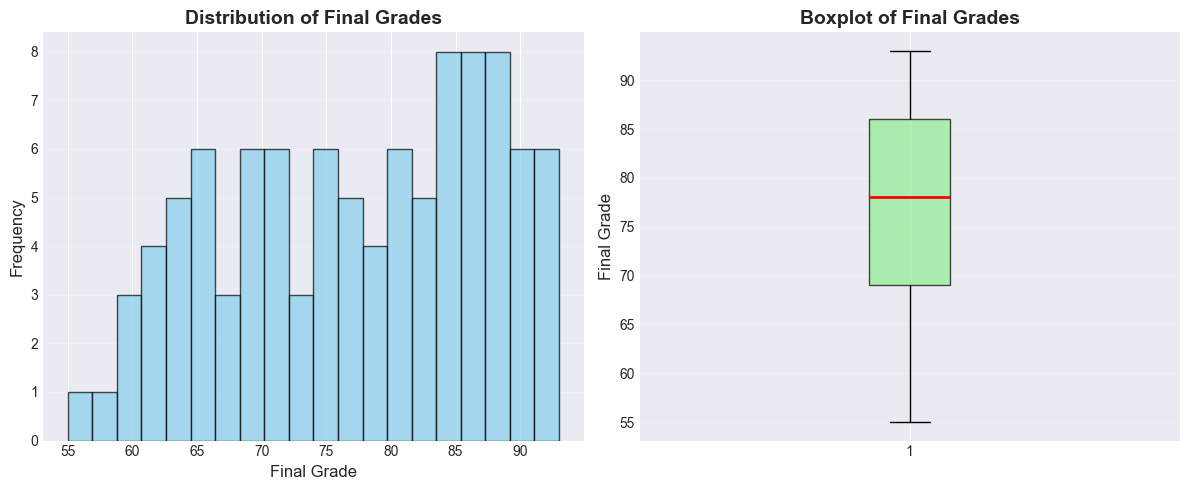

Mean Final Grade: 77.28
Median Final Grade: 78.00
Std Dev: 10.19


In [12]:
# Distribution of Final Grades (Target Variable)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Final_Grade'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Final Grade', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Final Grades', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df['Final_Grade'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
plt.ylabel('Final Grade', fontsize=12)
plt.title('Boxplot of Final Grades', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Final Grade: {df['Final_Grade'].mean():.2f}")
print(f"Median Final Grade: {df['Final_Grade'].median():.2f}")
print(f"Std Dev: {df['Final_Grade'].std():.2f}")

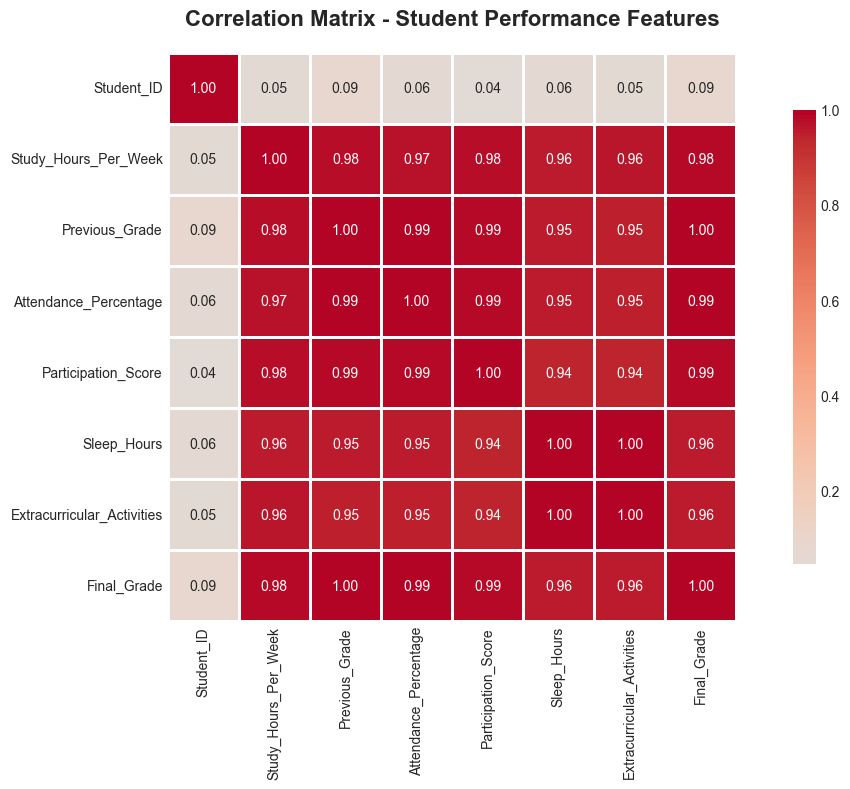


=== Features Correlation with Final Grade ===
Final_Grade                   1.000000
Previous_Grade                0.998573
Attendance_Percentage         0.990699
Participation_Score           0.985572
Study_Hours_Per_Week          0.983902
Sleep_Hours                   0.957855
Extracurricular_Activities    0.955058
Student_ID                    0.088827
Name: Final_Grade, dtype: float64


In [13]:
# Correlation Analysis
plt.figure(figsize=(12, 8))

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Student Performance Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Features most correlated with Final Grade
print("\n=== Features Correlation with Final Grade ===")
final_grade_corr = correlation_matrix['Final_Grade'].sort_values(ascending=False)
print(final_grade_corr)

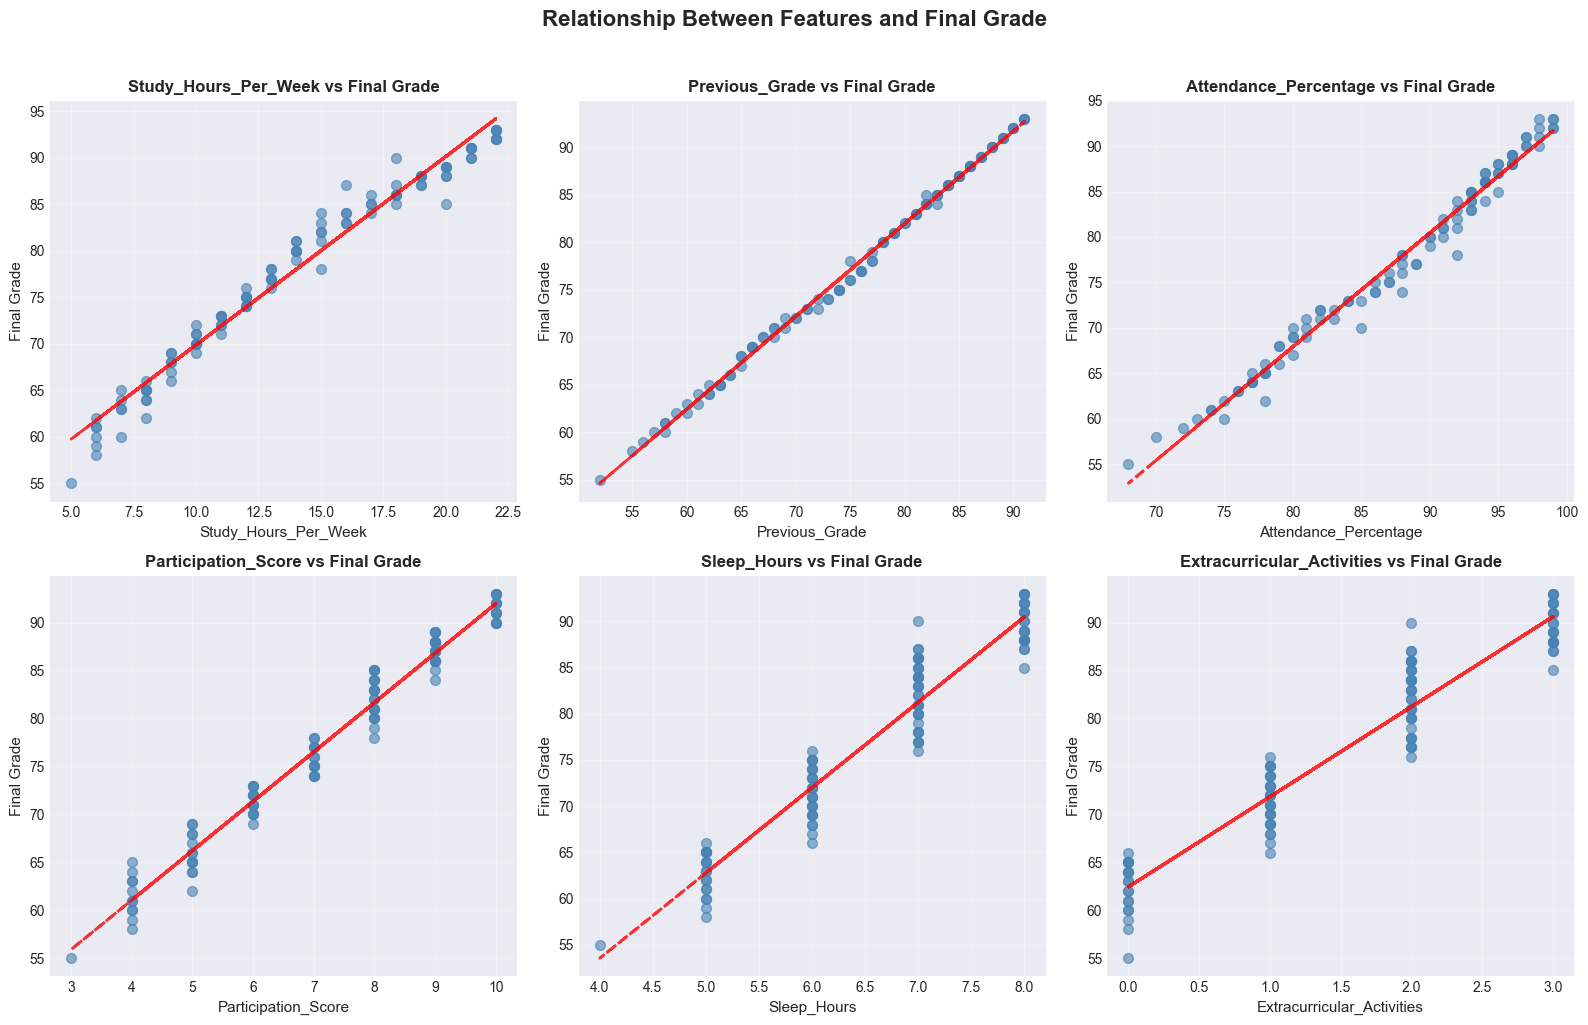

In [14]:
# Scatter plots for key features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Relationship Between Features and Final Grade', fontsize=16, fontweight='bold', y=1.02)

features_to_plot = ['Study_Hours_Per_Week', 'Previous_Grade', 'Attendance_Percentage', 
                    'Participation_Score', 'Sleep_Hours', 'Extracurricular_Activities']

for idx, feature in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3
    axes[row, col].scatter(df[feature], df['Final_Grade'], alpha=0.6, s=50, color='steelblue')
    axes[row, col].set_xlabel(feature, fontsize=11)
    axes[row, col].set_ylabel('Final Grade', fontsize=11)
    axes[row, col].set_title(f'{feature} vs Final Grade', fontsize=12, fontweight='bold')
    axes[row, col].grid(alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df[feature], df['Final_Grade'], 1)
    p = np.poly1d(z)
    axes[row, col].plot(df[feature], p(df[feature]), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

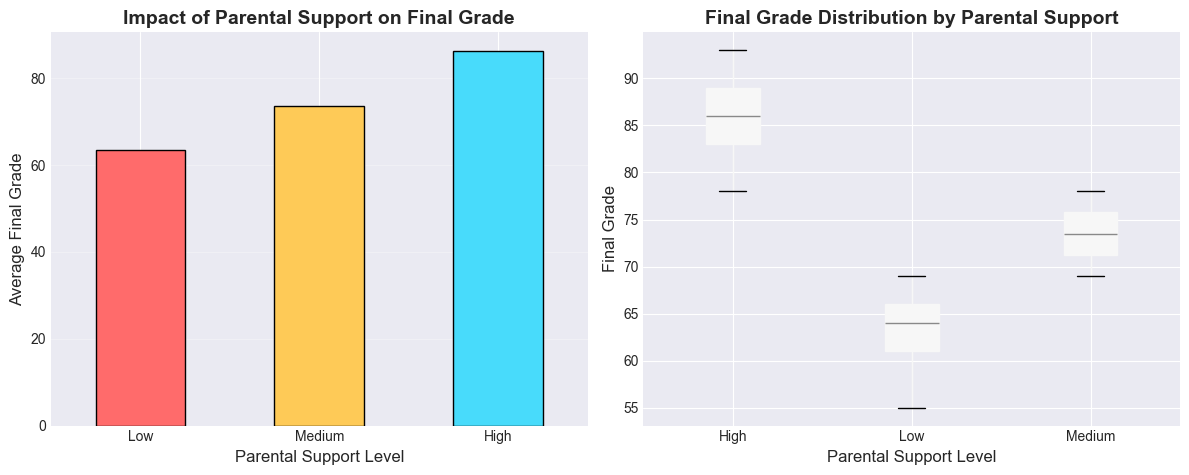


=== Average Final Grade by Parental Support ===
                       mean  count       std
Parental_Support                            
High              86.244898     49  4.085190
Low               63.560000     25  3.536477
Medium            73.576923     26  2.685860


In [15]:
# Parental Support Analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
parental_support_avg = df.groupby('Parental_Support')['Final_Grade'].mean().sort_values()
parental_support_avg.plot(kind='bar', color=['#ff6b6b', '#feca57', '#48dbfb'], edgecolor='black')
plt.xlabel('Parental Support Level', fontsize=12)
plt.ylabel('Average Final Grade', fontsize=12)
plt.title('Impact of Parental Support on Final Grade', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
df.boxplot(column='Final_Grade', by='Parental_Support', ax=plt.gca(), patch_artist=True)
plt.xlabel('Parental Support Level', fontsize=12)
plt.ylabel('Final Grade', fontsize=12)
plt.title('Final Grade Distribution by Parental Support', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

print("\n=== Average Final Grade by Parental Support ===")
print(df.groupby('Parental_Support')['Final_Grade'].agg(['mean', 'count', 'std']))

## 4. Data Preprocessing and Feature Engineering

In [16]:
# Create a copy for preprocessing
df_processed = df.copy()

# Encode categorical variable (Parental_Support)
label_encoder = LabelEncoder()
df_processed['Parental_Support_Encoded'] = label_encoder.fit_transform(df_processed['Parental_Support'])

print("Parental Support Encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label}: {i}")

# Feature Engineering: Create new features
df_processed['Study_Efficiency'] = df_processed['Study_Hours_Per_Week'] * df_processed['Attendance_Percentage'] / 100
df_processed['Overall_Engagement'] = (df_processed['Participation_Score'] + df_processed['Extracurricular_Activities']) / 2
df_processed['Academic_Balance'] = df_processed['Study_Hours_Per_Week'] / (df_processed['Sleep_Hours'] + 1)  # +1 to avoid division by zero

print("\n✓ Feature engineering completed!")
print(f"New features created: Study_Efficiency, Overall_Engagement, Academic_Balance")
print(f"\nTotal features now: {df_processed.shape[1]}")

Parental Support Encoding:
  High: 0
  Low: 1
  Medium: 2

✓ Feature engineering completed!
New features created: Study_Efficiency, Overall_Engagement, Academic_Balance

Total features now: 13


In [17]:
# Prepare features (X) and target (y)
feature_columns = ['Study_Hours_Per_Week', 'Previous_Grade', 'Attendance_Percentage', 
                   'Participation_Score', 'Sleep_Hours', 'Extracurricular_Activities',
                   'Parental_Support_Encoded', 'Study_Efficiency', 'Overall_Engagement', 
                   'Academic_Balance']

X = df_processed[feature_columns]
y = df_processed['Final_Grade']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeatures used:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")

Features (X) shape: (100, 10)
Target (y) shape: (100,)

Features used:
  1. Study_Hours_Per_Week
  2. Previous_Grade
  3. Attendance_Percentage
  4. Participation_Score
  5. Sleep_Hours
  6. Extracurricular_Activities
  7. Parental_Support_Encoded
  8. Study_Efficiency
  9. Overall_Engagement
  10. Academic_Balance


In [18]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set: {(X_train.shape[0]/X.shape[0])*100:.1f}%")
print(f"Testing set: {(X_test.shape[0]/X.shape[0])*100:.1f}%")

Training set size: 80 samples
Testing set size: 20 samples

Training set: 80.0%
Testing set: 20.0%


In [19]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Feature scaling completed!")
print("\nScaled features - Training set statistics:")
print(f"  Mean: {X_train_scaled.mean():.4f}")
print(f"  Std Dev: {X_train_scaled.std():.4f}")

✓ Feature scaling completed!

Scaled features - Training set statistics:
  Mean: 0.0000
  Std Dev: 1.0000


## 5. Model Training and Evaluation

In [20]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.1, random_state=42),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

print("Models initialized:")
for i, model_name in enumerate(models.keys(), 1):
    print(f"  {i}. {model_name}")

Models initialized:
  1. Linear Regression
  2. Ridge Regression
  3. Lasso Regression
  4. Decision Tree
  5. Random Forest
  6. Gradient Boosting


In [21]:
# Train and evaluate all models
results = {}

print("\n" + "="*80)
print("MODEL TRAINING AND EVALUATION")
print("="*80 + "\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_mean = cv_scores.mean()
    
    # Store results
    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'cv_r2': cv_mean,
        'y_test_pred': y_test_pred
    }
    
    print(f"  ✓ Training R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
    print(f"  ✓ Test RMSE: {test_rmse:.4f} | Test MAE: {test_mae:.4f}")
    print(f"  ✓ Cross-Validation R² (5-fold): {cv_mean:.4f}\n")

print("="*80)
print("✓ All models trained successfully!")
print("="*80)


MODEL TRAINING AND EVALUATION

Training Linear Regression...
  ✓ Training R²: 0.9986 | Test R²: 0.9965
  ✓ Test RMSE: 0.5545 | Test MAE: 0.4731
  ✓ Cross-Validation R² (5-fold): 0.9977

Training Ridge Regression...
  ✓ Training R²: 0.9966 | Test R²: 0.9924
  ✓ Test RMSE: 0.8133 | Test MAE: 0.6003
  ✓ Cross-Validation R² (5-fold): 0.9946

Training Lasso Regression...
  ✓ Training R²: 0.9984 | Test R²: 0.9963
  ✓ Test RMSE: 0.5663 | Test MAE: 0.4662
  ✓ Cross-Validation R² (5-fold): 0.9978

Training Decision Tree...
  ✓ Training R²: 0.9999 | Test R²: 0.9911
  ✓ Test RMSE: 0.8803 | Test MAE: 0.6500
  ✓ Cross-Validation R² (5-fold): 0.9890

Training Random Forest...
  ✓ Training R²: 0.9992 | Test R²: 0.9878
  ✓ Test RMSE: 1.0294 | Test MAE: 0.7410
  ✓ Cross-Validation R² (5-fold): 0.9917

Training Gradient Boosting...
  ✓ Training R²: 0.9999 | Test R²: 0.9870
  ✓ Test RMSE: 1.0642 | Test MAE: 0.7100
  ✓ Cross-Validation R² (5-fold): 0.9933

✓ All models trained successfully!


In [22]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train R²': [results[m]['train_r2'] for m in results],
    'Test R²': [results[m]['test_r2'] for m in results],
    'Test RMSE': [results[m]['test_rmse'] for m in results],
    'Test MAE': [results[m]['test_mae'] for m in results],
    'CV R² (5-fold)': [results[m]['cv_r2'] for m in results]
})

# Sort by Test R² score
comparison_df = comparison_df.sort_values('Test R²', ascending=False).reset_index(drop=True)

print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(comparison_df.to_string(index=False))

# Best model
best_model_name = comparison_df.iloc[0]['Model']
best_test_r2 = comparison_df.iloc[0]['Test R²']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test R² Score: {best_test_r2:.4f} ({best_test_r2*100:.2f}% accuracy)")


=== MODEL PERFORMANCE COMPARISON ===
            Model  Train R²  Test R²  Test RMSE  Test MAE  CV R² (5-fold)
Linear Regression  0.998615 0.996471   0.554536  0.473052        0.997689
 Lasso Regression  0.998423 0.996320   0.566273  0.466239        0.997816
 Ridge Regression  0.996556 0.992410   0.813303  0.600296        0.994562
    Decision Tree  0.999941 0.991107   0.880341  0.650000        0.989018
    Random Forest  0.999169 0.987839   1.029448  0.740967        0.991674
Gradient Boosting  0.999941 0.987005   1.064168  0.710044        0.993332

🏆 Best Model: Linear Regression
   Test R² Score: 0.9965 (99.65% accuracy)


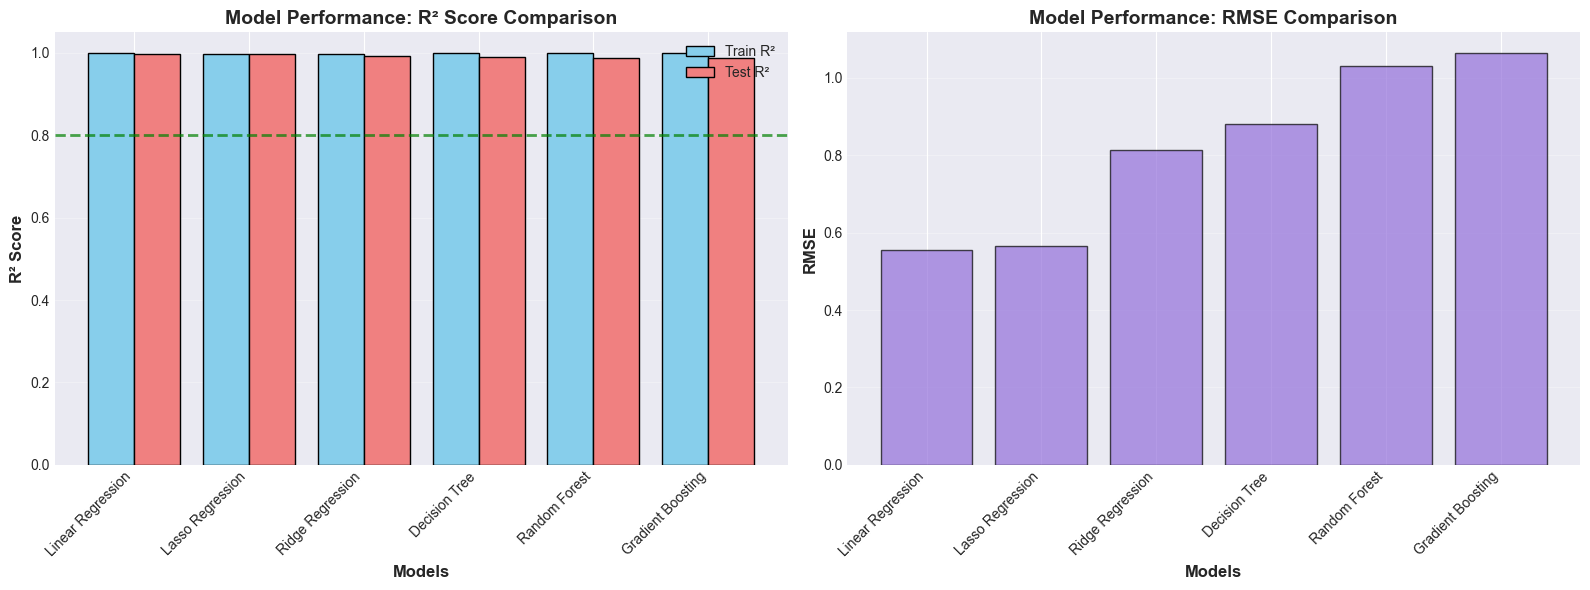

In [23]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² Score Comparison
x_pos = np.arange(len(comparison_df))
axes[0].bar(x_pos - 0.2, comparison_df['Train R²'], 0.4, label='Train R²', color='skyblue', edgecolor='black')
axes[0].bar(x_pos + 0.2, comparison_df['Test R²'], 0.4, label='Test R²', color='lightcoral', edgecolor='black')
axes[0].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance: R² Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0.8, color='green', linestyle='--', linewidth=2, label='80% Target', alpha=0.7)

# RMSE Comparison
axes[1].bar(comparison_df['Model'], comparison_df['Test RMSE'], color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE', fontsize=12, fontweight='bold')
axes[1].set_title('Model Performance: RMSE Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Best Model Analysis

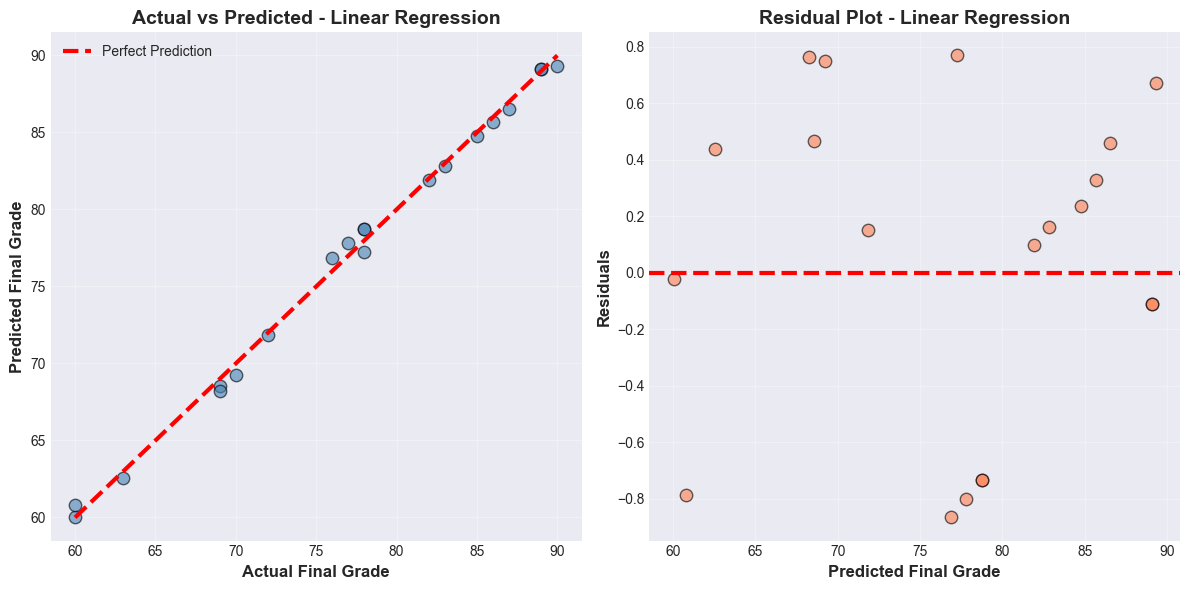


Residual Statistics for Linear Regression:
  Mean Residual: 0.0559
  Std Dev of Residuals: 0.5660


In [24]:
# Get best model
best_model = results[best_model_name]['model']
y_test_pred_best = results[best_model_name]['y_test_pred']

# Actual vs Predicted plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_best, alpha=0.6, s=80, color='steelblue', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Perfect Prediction')
plt.xlabel('Actual Final Grade', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Final Grade', fontsize=12, fontweight='bold')
plt.title(f'Actual vs Predicted - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Residual plot
plt.subplot(1, 2, 2)
residuals = y_test - y_test_pred_best
plt.scatter(y_test_pred_best, residuals, alpha=0.6, s=80, color='coral', edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--', lw=3)
plt.xlabel('Predicted Final Grade', fontsize=12, fontweight='bold')
plt.ylabel('Residuals', fontsize=12, fontweight='bold')
plt.title(f'Residual Plot - {best_model_name}', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics for {best_model_name}:")
print(f"  Mean Residual: {residuals.mean():.4f}")
print(f"  Std Dev of Residuals: {residuals.std():.4f}")

In [25]:
# Feature Importance (for tree-based models)
if best_model_name in ['Decision Tree', 'Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], 
             color='teal', edgecolor='black', alpha=0.7)
    plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n=== Feature Importance ===")
    print(feature_importance.to_string(index=False))
else:
    print(f"\nNote: Feature importance is not available for {best_model_name}")


Note: Feature importance is not available for Linear Regression


## 7. Key Insights and Conclusions

In [26]:
print("="*80)
print("KEY INSIGHTS FROM STUDENT PERFORMANCE PREDICTION")
print("="*80)

print("\n1. MODEL PERFORMANCE:")
print(f"   • Best Model: {best_model_name}")
print(f"   • Test Accuracy (R²): {best_test_r2*100:.2f}%")
print(f"   • RMSE: {results[best_model_name]['test_rmse']:.4f}")
print(f"   • MAE: {results[best_model_name]['test_mae']:.4f}")

print("\n2. MOST INFLUENTIAL FACTORS:")
top_correlations = correlation_matrix['Final_Grade'].sort_values(ascending=False)[1:4]
for feature, corr in top_correlations.items():
    print(f"   • {feature}: {corr:.3f} correlation")

print("\n3. PARENTAL SUPPORT IMPACT:")
support_impact = df.groupby('Parental_Support')['Final_Grade'].mean()
for level, avg_grade in support_impact.items():
    print(f"   • {level} Support: Average grade {avg_grade:.2f}")

print("\n4. DATA QUALITY:")
print(f"   • Total samples: {len(df)}")
print(f"   • Missing values: {df.isnull().sum().sum()}")
print(f"   • Features used: {len(feature_columns)}")

print("\n5. RECOMMENDATIONS:")
print("   • Students should focus on maintaining high attendance (strong correlation)")
print("   • Previous academic performance is a strong predictor of future success")
print("   • Parental support significantly impacts student outcomes")
print("   • Balanced study hours with adequate sleep improves performance")

print("\n" + "="*80)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*80)

KEY INSIGHTS FROM STUDENT PERFORMANCE PREDICTION

1. MODEL PERFORMANCE:
   • Best Model: Linear Regression
   • Test Accuracy (R²): 99.65%
   • RMSE: 0.5545
   • MAE: 0.4731

2. MOST INFLUENTIAL FACTORS:
   • Previous_Grade: 0.999 correlation
   • Attendance_Percentage: 0.991 correlation
   • Participation_Score: 0.986 correlation

3. PARENTAL SUPPORT IMPACT:
   • High Support: Average grade 86.24
   • Low Support: Average grade 63.56
   • Medium Support: Average grade 73.58

4. DATA QUALITY:
   • Total samples: 100
   • Missing values: 0
   • Features used: 10

5. RECOMMENDATIONS:
   • Students should focus on maintaining high attendance (strong correlation)
   • Previous academic performance is a strong predictor of future success
   • Parental support significantly impacts student outcomes
   • Balanced study hours with adequate sleep improves performance

PROJECT COMPLETED SUCCESSFULLY!


## 8. Model Saving (Optional)

In [27]:
# Save the best model for future use
import pickle

# Save model
with open('best_student_performance_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"✓ Best model ({best_model_name}) saved as 'best_student_performance_model.pkl'")
print("✓ Feature scaler saved as 'feature_scaler.pkl'")
print("\nThese files can be loaded later for making predictions on new data.")

✓ Best model (Linear Regression) saved as 'best_student_performance_model.pkl'
✓ Feature scaler saved as 'feature_scaler.pkl'

These files can be loaded later for making predictions on new data.
